# The **autoregressive** edge sampler

`MCTS` can build an edge three ways. This notebook is about the third one.

| `edge_mode` | how the edge is built | denoiser passes / edge |
|---|---|---|
| `imagine` | action and state denoised **jointly** over the whole horizon | `K` |
| `two_stage` | policy over the whole horizon, then the world model | `2K` |
| **`autoregressive`** | **one frame at a time**: `policy(H=1)` → (+ noise) → `transition(H=1)` → append the realised `(s,a)` → repeat | **`2HK`** |

Autoregressive is the causally faithful one: every action is conditioned on the state the
model *actually* produced, not on a state co-denoised with it. It also unlocks a knob the
other samplers do not have — **`action_noise`**, exploration noise added directly to each
sampled action.

That matters because of how the other samplers buy diversity. `ctx_noise` corrupts the
*observation context*, and past ~0.7 the model leaves its manifold and the edges become
fiction. `action_noise` perturbs the **action** and lets the world model respond, so the
states stay on-manifold by construction. The hypothesis this notebook tests:

> **`action_noise` under `autoregressive` buys diversity without the coherence loss that
> `ctx_noise` causes — but at `2H` times the cost. Is it worth it?**

**Sections.** 1 mechanism & cost · 2 diversity (the `action_noise` lever) · 3 coherence ·
4 inside a tree · 5 what to put in the sweep grid.

> **Runtime warning.** AR is ~`2H`x slower per edge than `imagine`. Everything below is
> deliberately small (`H<=12`, `B<=8`, few iterations). Scale up only after reading §1.2.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import mediapy
import cv2

torch.manual_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
pd.set_option('display.width', 220)
print('device:', DEVICE)

device: cuda:0


In [2]:
from dreamerv4uwm.planning.experiments.study.model import load_world_model, make_decode_fn, model_dims
from dreamerv4uwm.planning.experiments.study.data import make_dataset, encode_window

DYN_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
TOK_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'
DATA_DIR = '/home/mim-server/datasets/pushT/h5/play'

denoiser, tokenizer, cfg = load_world_model(
    dynamics_ckpt=DYN_CKPT, tokenizer_ckpt=TOK_CKPT, config_name='dynamics/pushT-large',
    overrides=['denoiser.horizon_aware=false'], device=DEVICE)
decode = make_decode_fn(tokenizer, DEVICE)
DIMS = model_dims(denoiser)

dataset = make_dataset(DATA_DIR, window_size=64)
WINDOW_IDX = 1111
latents, actions = encode_window(dataset, tokenizer, WINDOW_IDX, DEVICE, DIMS['n_actions'])
print(DIMS, '| dataset windows:', len(dataset))

/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Train split: 64694 windows from 11 episodes
{'num_noise_levels': 128, 'num_latent_tokens': 256, 'latent_dim': 32, 'n_actions': 2} | dataset windows: 64694


In [3]:
# --- display helpers (identical to planning-mcts-experiments_v2.ipynb) ----------------------
def to_rgb(lat):
    v = decode(lat[:, None])[:, 0]
    return (v.permute(0, 2, 3, 1).clamp(0, 1) * 255).to(torch.uint8).cpu().numpy()

def show_state(lat, *, ax=None, annotate=True, title=None, figsize=(3.4, 3.4)):
    '''One latent state (N,D) -> decoded frame with the reward overlay. Returns the score.'''
    score, dbg, rgb = reward.score_latent(lat)
    img = annotate_t(rgb, dbg) if annotate else rgb
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'r = {score:.3f}' if title is None else title, fontsize=9)
    if own:
        plt.tight_layout(); plt.show()
    return score

def show_states(lats, *, titles=None, ncols=8, annotate=False, title=None, cell=2.1):
    '''Grid of decoded latent states (M,N,D).'''
    M = int(lats.shape[0]); ncol = max(1, min(M, ncols)); nrow = -(-M // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(cell * ncol, cell * 1.18 * nrow), squeeze=False)
    rgb = None if annotate else to_rgb(lats)
    for k in range(nrow * ncol):
        ax = axes[k // ncol][k % ncol]; ax.axis('off')
        if k >= M: continue
        lab = titles[k] if titles is not None else f'#{k}'
        if annotate: show_state(lats[k], ax=ax, annotate=True, title=lab)
        else: ax.imshow(rgb[k]); ax.set_title(lab, fontsize=8)
    if title: fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def filmstrip(lat_seq, n=8, scores=None, title=None, row_h=2.4):
    '''(T,N,D) -> a row of n evenly-spaced decoded frames.'''
    T = lat_seq.shape[0]; idx = np.linspace(0, T - 1, min(n, T), dtype=int)
    rgb = to_rgb(lat_seq[idx])
    fig, axes = plt.subplots(1, len(idx), figsize=(1.9 * len(idx), row_h))
    for k, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(rgb[k]); ax.axis('off')
        ax.set_title(f't={idx[k]}' + (f'\nr={scores[idx[k]]:.2f}' if scores is not None else ''), fontsize=8)
    if title: fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def plotVideo(video, fps=10, label=True):
    arr = (video.detach().cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255)
    arr = np.ascontiguousarray(arr.clip(0, 255).astype(np.uint8))
    if label:
        for i in range(arr.shape[0]):
            cv2.putText(arr[i], f'{i}', (8, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
    mediapy.show_video(arr, fps=fps)

def plotLatentVideo(lat_seq, fps=10, **kw):
    plotVideo(decode(lat_seq[None])[0], fps=fps, **kw)

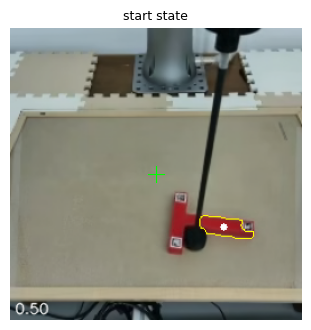

start reward = 0.497


In [4]:
from dreamerv4uwm.planning import (rollout as R, MCTS, PlanConfig,
                                   TCenterReward, TCenterAngleReward, annotate_t)
from dreamerv4uwm.planning.experiments.study.descriptors import TPoseDescriptor
from dreamerv4uwm.planning.experiments.study.metrics import (compute_tree_metrics, _pairwise,
                                                             _eff_count, _duplicate_rate)
from dreamerv4uwm.planning.experiments.study.run_tree import run_one_tree, _plan_peak, _plan_last

SEG_KW  = dict(center_xy=(0.5, 0.5), sigma=0.25)
reward     = TCenterReward(decode_fn=decode, **SEG_KW)
descriptor = TPoseDescriptor(decode_fn=decode, dup_eps=0.05, **SEG_KW)

T_CTX, K_STEPS = 8, 6
cz = latents[:, 24:24 + T_CTX].clone()
ca = actions[:, 24:24 + T_CTX].clone()
print(f'start reward = {show_state(cz[0, -1], title="start state"):.3f}')

# 1 — Mechanism and cost

## 1.1 One edge from each sampler

Same context, same seed, same horizon. Only the construction differs.

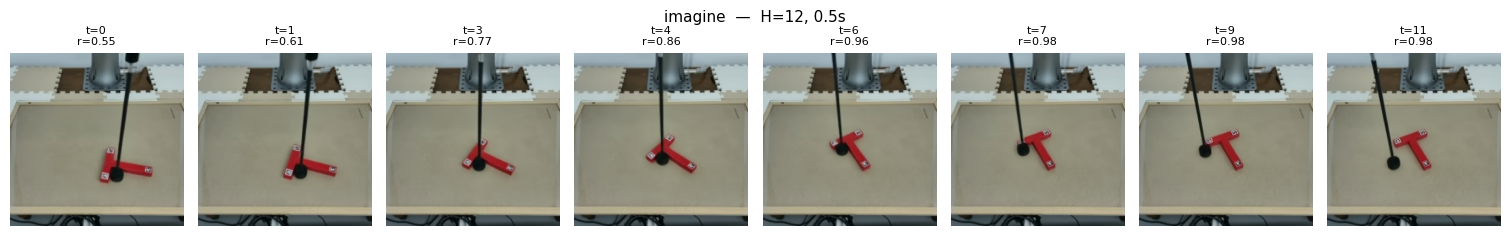

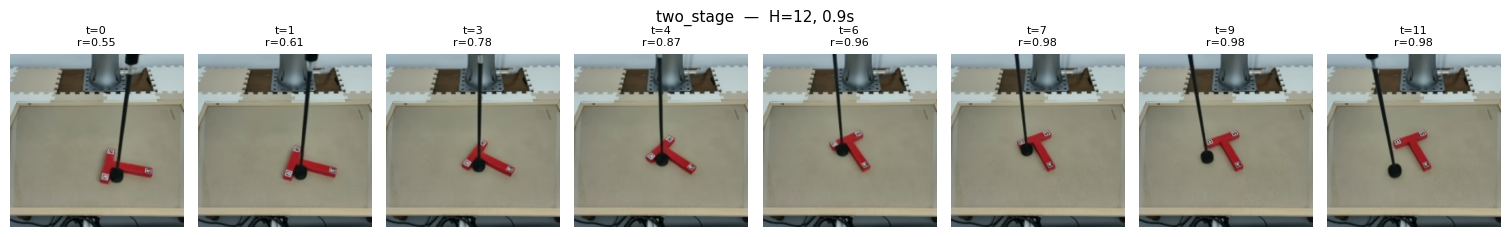

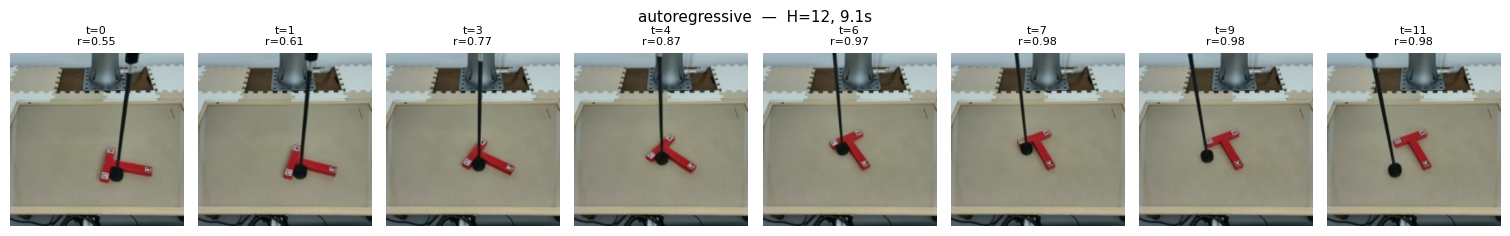

In [5]:
H_DEMO = 12

def sample_edge(mode, *, H=H_DEMO, B=1, ctx_noise=0.5, action_temp=1.0,
                action_noise=0.0, action_noise_dist='normal', K=K_STEPS, seed=0):
    '''One call for any edge_mode. Returns (z (B,H,N,D), a (B,H,n_act), seconds).'''
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    t = time.time()
    if mode == 'imagine':
        z, a = R.imagine(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                         action_temp=action_temp, generator=g)
    elif mode == 'two_stage':
        a = R.policy(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                     action_temp=action_temp, generator=g)
        z = R.transition(denoiser, cz, ca, a, K=K, ctx_noise=ctx_noise, generator=g)
    elif mode == 'autoregressive':
        z, a = R.autoregressive(denoiser, cz, ca, H, B=B, K=K, ctx_noise=ctx_noise,
                                action_temp=action_temp, action_noise=action_noise,
                                action_noise_dist=action_noise_dist, generator=g)
    else:
        raise ValueError(mode)
    return z, a, time.time() - t

for mode in ['imagine', 'two_stage', 'autoregressive']:
    z, a, secs = sample_edge(mode, seed=0)
    filmstrip(z[0], n=8, scores=reward(z[0]).cpu().numpy(),
              title=f'{mode}  —  H={H_DEMO}, {secs:.1f}s')

## 1.2 Cost — the `2H` law

`imagine` is `K` denoiser passes per edge whatever the horizon; `autoregressive` is `2HK`,
because each of the `H` frames costs a `policy` call *and* a `transition` call. So AR cost is
**linear in the horizon** while the others are flat. Measure it — this number sets the SLURM
`--time` for `sweep_autoregressive.yaml`.

In [6]:
HS = [4, 8, 12]
timing = []
for H in HS:
    for mode in ['imagine', 'two_stage', 'autoregressive']:
        _ = sample_edge(mode, H=H, B=2, seed=1)                 # warm-up (excluded)
        _, _, secs = sample_edge(mode, H=H, B=2, seed=2)
        timing.append(dict(H=H, mode=mode, secs=secs))
        print(f'H={H:2d}  {mode:16s} {secs:6.2f}s')

tdf = pd.DataFrame(timing).pivot(index='H', columns='mode', values='secs')
tdf['AR / imagine'] = tdf.autoregressive / tdf.imagine
tdf['2H (predicted)'] = 2 * np.array(HS)
tdf.round(2)

H= 4  imagine            0.62s
H= 4  two_stage          1.25s
H= 4  autoregressive     4.30s
H= 8  imagine            0.81s
H= 8  two_stage          1.63s
H= 8  autoregressive    10.32s
H=12  imagine            0.99s
H=12  two_stage          1.99s
H=12  autoregressive    17.29s


mode,autoregressive,imagine,two_stage,AR / imagine,2H (predicted)
H,,,,,
4,4.30,0.62,1.25,6.92,8
8,10.32,0.81,1.63,12.74,16
12,17.29,0.99,1.99,17.39,24


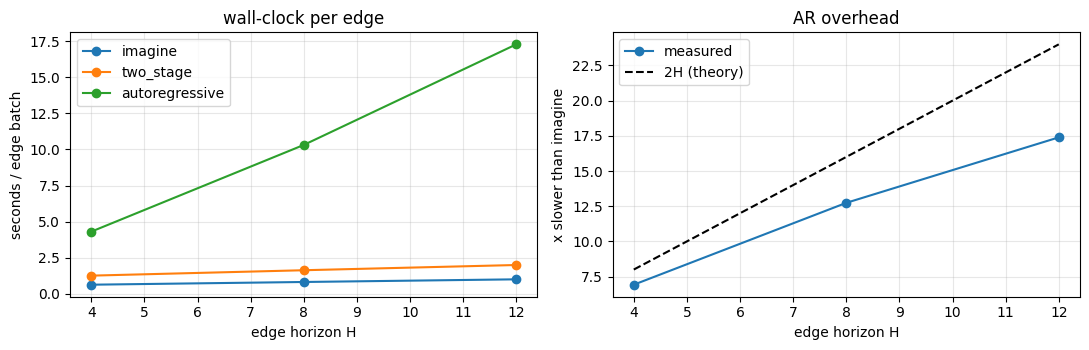

If measured << 2H, the GPU is not saturated at this batch size and AR is cheaper in practice than the pass count suggests — check again at the B you plan to sweep.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for m in ['imagine', 'two_stage', 'autoregressive']:
    ax[0].plot(tdf.index, tdf[m], 'o-', label=m)
ax[0].set_xlabel('edge horizon H'); ax[0].set_ylabel('seconds / edge batch')
ax[0].set_title('wall-clock per edge'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(tdf.index, tdf['AR / imagine'], 'o-', label='measured')
ax[1].plot(tdf.index, tdf['2H (predicted)'], 'k--', label='2H (theory)')
ax[1].set_xlabel('edge horizon H'); ax[1].set_ylabel('x slower than imagine')
ax[1].set_title('AR overhead'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('If measured << 2H, the GPU is not saturated at this batch size and AR is cheaper '
      'in practice than the pass count suggests — check again at the B you plan to sweep.')

# 2 — Diversity: the `action_noise` lever

The AR sampler's own knob. `action_noise` perturbs each sampled action *after* the policy and
*before* the world-model step, so the resulting states are genuine model responses to
perturbed actions — on-manifold by construction, unlike `ctx_noise` which corrupts the state
estimate itself.

**The decisive test: `ctx_noise = 0`.** Under `imagine`, a clean context gives a sharply peaked
conditional and the edges collapse (that is the *collapsed* regime). If `action_noise` alone
opens the fan-out at `ctx_noise = 0`, AR has a diversity source the other samplers lack.

In [8]:
def characterize(z, a, *, B):
    '''Diversity of a sibling set, using the same functions metrics.py uses in the tree.'''
    A = a.reshape(B, -1).float().cpu().numpy()
    act_div, act_dmin = _pairwise(A)
    feats, found = descriptor(z[:, -1])
    F = feats[found]
    m = dict(action_div=act_div, action_dmin=act_dmin, found_frac=float(found.mean()),
             edge_val_std=float(reward(z[:, -1]).std()),
             edge_val_mean=float(reward(z[:, -1]).mean()))
    if F.shape[0] >= 2:
        m['outcome_div'], m['outcome_dmin'] = _pairwise(F)
        m['bci'] = 1.0 - _eff_count(F, descriptor.dup_eps) / B
        m['duplicate_rate'] = _duplicate_rate(F, descriptor.dup_eps)
    return m

In [9]:
B_EDGES = 8
NOISES  = [0.0, 0.1, 0.3, 0.5]          # the grid in config/sweep_autoregressive.yaml

rows, edges = [], {}
for an in NOISES:
    z, a, secs = sample_edge('autoregressive', B=B_EDGES, ctx_noise=0.0,
                             action_noise=an, seed=11)
    m = characterize(z, a, B=B_EDGES); m.update(action_noise=an, secs=round(secs, 1))
    rows.append(m); edges[an] = z
    print(f"action_noise={an:.1f}  action_div={m['action_div']:6.3f}  "
          f"outcome_div={m.get('outcome_div', float('nan')):.3f}  "
          f"bci={m.get('bci', float('nan')):.2f}  edge_val_std={m['edge_val_std']:.3f}  ({secs:.0f}s)")

# the imagine control at the same clean context — expected to collapse
zi, ai, _ = sample_edge('imagine', B=B_EDGES, ctx_noise=0.0, seed=11)
mi = characterize(zi, ai, B=B_EDGES); mi.update(action_noise=np.nan, secs=np.nan)
print(f"\nimagine, ctx_noise=0   action_div={mi['action_div']:6.3f}  "
      f"outcome_div={mi.get('outcome_div', float('nan')):.3f}  bci={mi.get('bci', float('nan')):.2f}")

andf = pd.DataFrame(rows)
andf[['action_noise', 'action_div', 'outcome_div', 'bci', 'duplicate_rate',
      'edge_val_std', 'edge_val_mean', 'found_frac', 'secs']].round(3)

action_noise=0.0  action_div= 0.007  outcome_div=0.002  bci=0.88  edge_val_std=0.000  (83s)
action_noise=0.1  action_div= 0.624  outcome_div=0.003  bci=0.88  edge_val_std=0.000  (83s)
action_noise=0.3  action_div= 1.872  outcome_div=0.003  bci=0.88  edge_val_std=0.000  (83s)
action_noise=0.5  action_div= 3.120  outcome_div=0.003  bci=0.88  edge_val_std=0.000  (83s)

imagine, ctx_noise=0   action_div= 0.067  outcome_div=0.005  bci=0.88


,action_noise,action_div,outcome_div,bci,duplicate_rate,edge_val_std,edge_val_mean,found_frac,secs
0,0.0,0.007,0.002,0.875,1.0,0.0,0.982,1.0,82.6
1,0.1,0.624,0.003,0.875,1.0,0.0,0.983,1.0,82.8
2,0.3,1.872,0.003,0.875,1.0,0.0,0.983,1.0,83.4
3,0.5,3.120,0.003,0.875,1.0,0.0,0.983,1.0,83.4


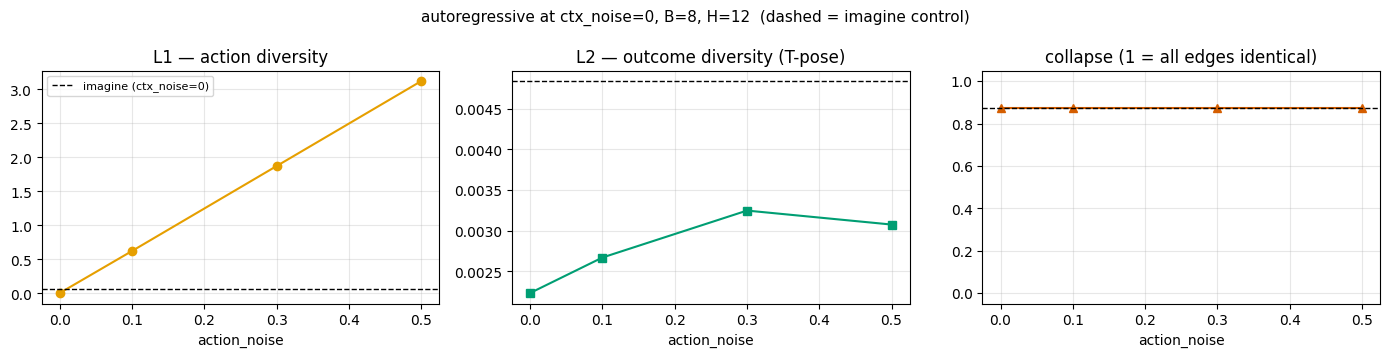

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(andf.action_noise, andf.action_div, 'o-', color='#E69F00')
ax[0].axhline(mi['action_div'], color='k', ls='--', lw=1, label='imagine (ctx_noise=0)')
ax[0].set_title('L1 — action diversity'); ax[0].legend(fontsize=8)
ax[1].plot(andf.action_noise, andf.outcome_div, 's-', color='#009E73')
ax[1].axhline(mi.get('outcome_div', np.nan), color='k', ls='--', lw=1)
ax[1].set_title('L2 — outcome diversity (T-pose)')
ax[2].plot(andf.action_noise, andf.bci, '^-', color='#D55E00')
ax[2].axhline(mi.get('bci', np.nan), color='k', ls='--', lw=1)
ax[2].set_ylim(-0.05, 1.05); ax[2].set_title('collapse (1 = all edges identical)')
for a_ in ax: a_.set_xlabel('action_noise'); a_.grid(alpha=.3)
fig.suptitle(f'autoregressive at ctx_noise=0, B={B_EDGES}, H={H_DEMO}  '
             '(dashed = imagine control)', fontsize=11)
plt.tight_layout(); plt.show()

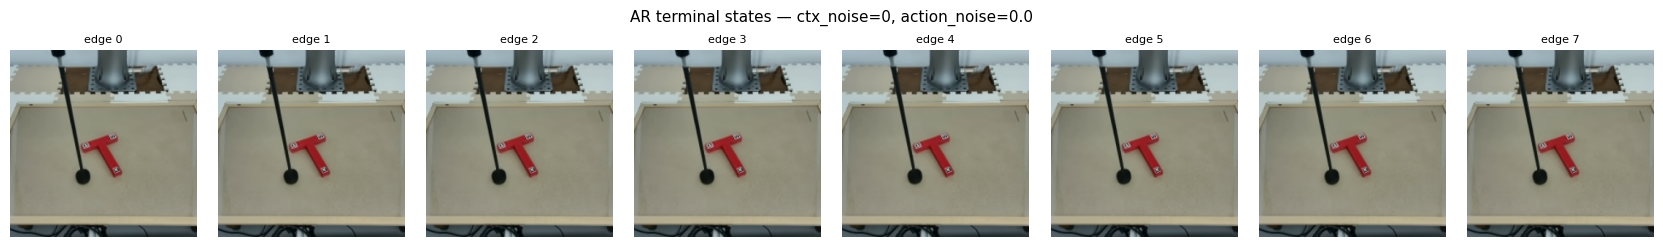

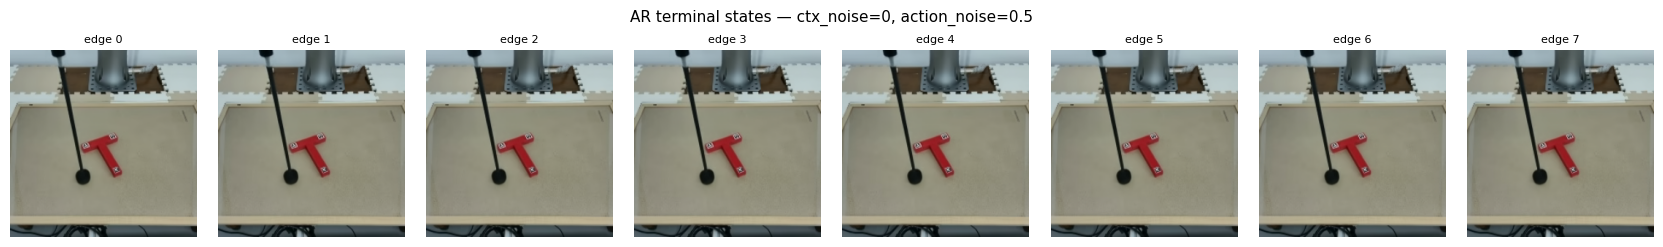

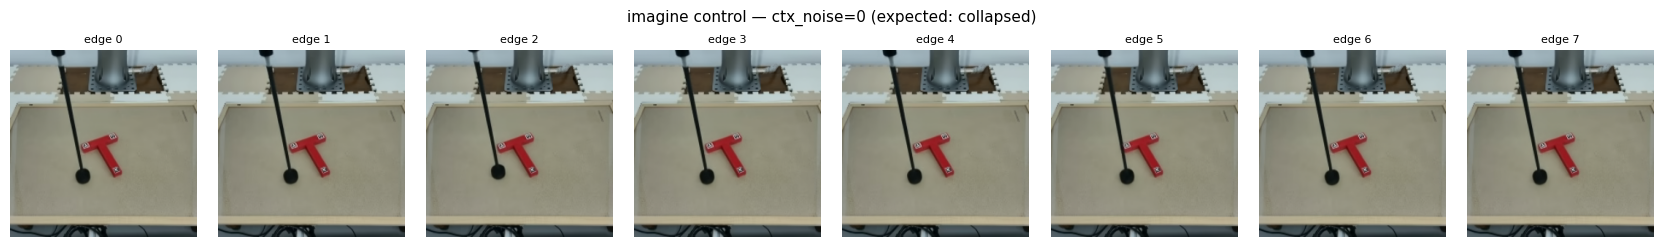

In [11]:
# seen directly: does added action noise actually separate the children?
for an in (0.0, 0.5):
    show_states(edges[an][:, -1], titles=[f'edge {k}' for k in range(B_EDGES)],
                title=f'AR terminal states — ctx_noise=0, action_noise={an}')
show_states(zi[:, -1], titles=[f'edge {k}' for k in range(B_EDGES)],
            title='imagine control — ctx_noise=0 (expected: collapsed)')

## 2.1 — Noise shape: `normal` vs `uniform`

In [12]:
rows = []
for dist in ['normal', 'uniform']:
    for an in [0.1, 0.3, 0.5]:
        z, a, _ = sample_edge('autoregressive', B=B_EDGES, ctx_noise=0.0,
                              action_noise=an, action_noise_dist=dist, seed=13)
        m = characterize(z, a, B=B_EDGES); m.update(action_noise=an, dist=dist)
        rows.append(m)
ndf = pd.DataFrame(rows)
print('(std-matched: uniform uses a = action_noise*sqrt(3), so both have the same std)')
ndf.pivot(index='action_noise', columns='dist',
          values=['action_div', 'outcome_div', 'bci', 'edge_val_std']).round(3)

(std-matched: uniform uses a = action_noise*sqrt(3), so both have the same std)


action_div         outcome_div            bci         edge_val_std        
dist             normal uniform      normal uniform normal uniform       normal uniform
action_noise                                                                           
0.1               0.743   0.662       0.002   0.002  0.875   0.875          0.0     0.0
0.3               2.229   1.988       0.002   0.002  0.875   0.875          0.0     0.0
0.5               3.715   3.314       0.002   0.002  0.875   0.875          0.0     0.0

## 2.2 — Is AR worth it at **matched compute**?

The honest comparison. AR costs `~2H` times more per edge, so at equal wall-clock `imagine`
can draw `~2H` times more edges. Does `B` AR edges beat `2H*B` imagine edges?

In [13]:
B_AR = 6
_, _, t_ar_unit = sample_edge('autoregressive', B=B_AR, ctx_noise=0.0, action_noise=0.3, seed=21)
_, _, t_im_unit = sample_edge('imagine', B=B_AR, ctx_noise=0.7, seed=21)
B_IM = int(max(B_AR, round(B_AR * t_ar_unit / max(t_im_unit, 1e-6))))    # compute-matched
print(f'AR B={B_AR}: {t_ar_unit:.1f}s   imagine B={B_AR}: {t_im_unit:.1f}s  '
      f'-> compute-matched imagine B={B_IM}')

z_ar, a_ar, s_ar = sample_edge('autoregressive', B=B_AR, ctx_noise=0.0, action_noise=0.3, seed=22)
z_im, a_im, s_im = sample_edge('imagine', B=B_IM, ctx_noise=0.7, seed=22)

cmp = pd.DataFrame([
    dict(sampler=f'autoregressive (B={B_AR}, action_noise=0.3, ctx_noise=0)',
         secs=round(s_ar, 1), best_edge_reward=float(reward(z_ar[:, -1]).max()),
         **characterize(z_ar, a_ar, B=B_AR)),
    dict(sampler=f'imagine (B={B_IM}, ctx_noise=0.7)',
         secs=round(s_im, 1), best_edge_reward=float(reward(z_im[:, -1]).max()),
         **characterize(z_im, a_im, B=B_IM)),
])
cmp[['sampler', 'secs', 'best_edge_reward', 'outcome_div', 'bci', 'edge_val_std', 'found_frac']].round(3)

AR B=6: 59.4s   imagine B=6: 3.6s  -> compute-matched imagine B=99


,sampler,secs,best_edge_reward,outcome_div,bci,edge_val_std,found_frac
0,"autoregressive (B=6, action_noise=0.3, ctx_noi...",60.2,0.983,0.002,0.833,0.000,1.0
1,"imagine (B=99, ctx_noise=0.7)",56.7,0.999,0.135,0.899,0.006,1.0


# 3 — Coherence

AR conditions every action on the **realised** previous state, so its `(state, action)` pairs
should be more internally consistent than a joint sample's. Test it without any ground truth:
take an edge's own actions, replay them through the **pure world model**
(`transition`, clean context) and compare the states it predicts with the states the edge
actually contains.

A large gap means the edge is a trajectory the model does not believe follows from its own
actions — diverse, perhaps, but fiction.

> *Caveat.* `transition` denoises the whole horizon jointly, whereas AR built it in `H`
> sequential single-frame steps, so a non-zero gap is expected for **both** samplers. The
> comparison between them is the informative part, not the absolute value.

In [14]:
def replay_gap(z_edge, a_edge, *, K=K_STEPS, seed=0):
    '''Replay an edge's own actions through the world model; return per-edge divergence
    in descriptor space (task-relevant) and in raw latent space.'''
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    z_wm = R.transition(denoiser, cz, ca, a_edge, K=K, ctx_noise=0.0, generator=g)  # (B,H,N,D)
    f_edge, ok_e = descriptor(z_edge[:, -1])
    f_wm,   ok_w = descriptor(z_wm[:, -1])
    ok = ok_e & ok_w
    d_phi = (np.linalg.norm(f_edge[ok] - f_wm[ok], axis=-1) if ok.any() else np.array([np.nan]))
    d_lat = (z_edge[:, -1] - z_wm[:, -1]).flatten(1).norm(dim=-1) / np.sqrt(
        z_edge.shape[-1] * z_edge.shape[-2])
    return dict(phi_gap=float(np.nanmean(d_phi)), latent_rms_gap=float(d_lat.mean()),
                both_found=float(ok.mean()))

rows = []
for label, mode, kw in [('AR (action_noise=0.3, ctx_noise=0)', 'autoregressive',
                         dict(ctx_noise=0.0, action_noise=0.3)),
                        ('AR (ctx_noise=0.7)', 'autoregressive', dict(ctx_noise=0.7)),
                        ('imagine (ctx_noise=0.0)', 'imagine', dict(ctx_noise=0.0)),
                        ('imagine (ctx_noise=0.7)', 'imagine', dict(ctx_noise=0.7)),
                        ('imagine (ctx_noise=0.9)', 'imagine', dict(ctx_noise=0.9))]:
    z, a, _ = sample_edge(mode, B=B_EDGES, seed=31, **kw)
    r = replay_gap(z, a); r.update(edge=label)
    rows.append(r)
    print(f"{label:36s} phi_gap={r['phi_gap']:.4f}  latent_rms_gap={r['latent_rms_gap']:.4f}")

gdf = pd.DataFrame(rows)[['edge', 'phi_gap', 'latent_rms_gap', 'both_found']]
gdf.round(4)

AR (action_noise=0.3, ctx_noise=0)   phi_gap=0.0032  latent_rms_gap=0.0613
AR (ctx_noise=0.7)                   phi_gap=0.0254  latent_rms_gap=0.1045
imagine (ctx_noise=0.0)              phi_gap=0.0029  latent_rms_gap=0.0655
imagine (ctx_noise=0.7)              phi_gap=0.0290  latent_rms_gap=0.1502
imagine (ctx_noise=0.9)              phi_gap=0.2963  latent_rms_gap=0.2691


,edge,phi_gap,latent_rms_gap,both_found
0,"AR (action_noise=0.3, ctx_noise=0)",0.0032,0.0613,1.0
1,AR (ctx_noise=0.7),0.0254,0.1045,1.0
2,imagine (ctx_noise=0.0),0.0029,0.0655,1.0
3,imagine (ctx_noise=0.7),0.0290,0.1502,1.0
4,imagine (ctx_noise=0.9),0.2963,0.2691,1.0


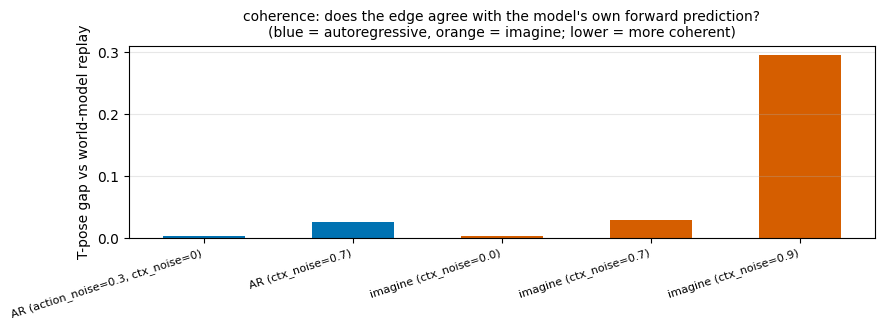

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(gdf))
ax.bar(x, gdf.phi_gap, 0.55, color=['#0072B2' if 'AR' in e else '#D55E00' for e in gdf.edge])
ax.set_xticks(x); ax.set_xticklabels(gdf.edge, rotation=18, ha='right', fontsize=8)
ax.set_ylabel('T-pose gap vs world-model replay'); ax.grid(alpha=.3, axis='y')
ax.set_title('coherence: does the edge agree with the model\'s own forward prediction?\n'
             '(blue = autoregressive, orange = imagine; lower = more coherent)', fontsize=10)
plt.tight_layout(); plt.show()

# 4 — Inside a tree

The only test that matters in the end. Build one AR tree and one `imagine` tree from the same
start state and compare with `run_one_tree` — the same function the sweep uses, so these rows
are schema-identical to the cluster shards.

Config follows `config/sweep_autoregressive.yaml`: shorter horizon, shallower tree, fewer
iterations than the main sweep, because each edge is expensive.

In [ ]:
AR_BASE = dict(horizon=12, branching=4, sim_horizon=12, sim_rollouts=2, n_iterations=16,
               c_ucb=0.5, gamma=0.98, n_min=0, max_depth=2, K_steps=6,
               action_temp=1.0, action_prior='normal', max_ctx=16)

TREES = {
    'AR  + action_noise=0.3': dict(edge_mode='autoregressive', ctx_noise=0.0, action_noise=0.3),
    'AR  + action_noise=0.0': dict(edge_mode='autoregressive', ctx_noise=0.0, action_noise=0.0),
    'AR  + ctx_noise=0.5':    dict(edge_mode='autoregressive', ctx_noise=0.5, action_noise=0.0),
    'imagine (ctx_noise=0.7)': dict(edge_mode='imagine', ctx_noise=0.7),
}

rows = []
for name, p in TREES.items():
    t = time.time()
    row = run_one_tree(denoiser=denoiser, reward_fn=reward, descriptor=descriptor,
                       plan_cfg=PlanConfig(**{**AR_BASE, **p}), ctx_z=cz, ctx_a=ca,
                       plan_seed=0, meta=dict(name=name), n_random=6)
    rows.append(row)
    print(f"{name:26s} {time.time()-t:6.1f}s  n_forward={row['n_forward']:5.0f}  "
          f"tree_peak={row['tree_peak']:.3f}  g_random_peak={row['g_random_peak']:+.3f}  "
          f"root_bci={row['root_bci']:.2f}")

tdf2 = pd.DataFrame(rows)
tdf2[['name', 'edge_mode', 'ctx_noise', 'action_noise', 'plan_secs', 'n_forward', 'n_nodes',
      'tree_peak', 'tree_last', 'g_random_peak', 'g_greedy_peak', 'g_random_last',
      'root_bci', 'root_action_div', 'root_outcome_div', 'val_std', 'visit_entropy']].round(3)

AR  + action_noise=0.3      738.9s  n_forward=  504  tree_peak=0.982  g_random_peak=-0.010  root_bci=0.75


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
x = np.arange(len(tdf2))
col = ['#0072B2' if m == 'autoregressive' else '#D55E00' for m in tdf2.edge_mode]
for a_, c, ttl in [(ax[0], 'g_random_peak', 'planning gain'),
                   (ax[1], 'root_bci', 'root collapse (lower better)'),
                   (ax[2], 'plan_secs', 'wall-clock (s)')]:
    a_.bar(x, tdf2[c], 0.55, color=col)
    a_.set_xticks(x); a_.set_xticklabels(tdf2.name, rotation=20, ha='right', fontsize=7)
    a_.set_title(f'{ttl}  [{c}]', fontsize=10); a_.grid(alpha=.3, axis='y')
ax[0].axhline(0, color='k', lw=1)
fig.suptitle('blue = autoregressive, orange = imagine', fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# the root children of the AR tree with and without added action noise
for name in ['AR  + action_noise=0.0', 'AR  + action_noise=0.3']:
    p = TREES[name]
    pl = MCTS(denoiser, reward, PlanConfig(**{**AR_BASE, **p}), seed=0, trace=True)
    o = pl.plan(cz, ca)
    kids = pl.root.children
    show_states(torch.stack([c.edge_z[-1] for c in kids]), annotate=True,
                titles=[f'child {k}\nn={c.n_visit}' for k, c in enumerate(kids)],
                title=f'{name}: root children')

# 5 — What to put in the sweep

`config/sweep_autoregressive.yaml` is already written; this section is about confirming its
grids and sizing the job before spending cluster hours.

Fill in from the cells above:

* **`action_noise` grid** `[0.0, 0.1, 0.3, 0.5]` — widen or shift it if §2 shows `bci` still
  near 1 at `0.5` (not enough noise) or `found_frac` dropping (too much: the T is being pushed
  out of frame or the states are degenerating).
* **`ctx_noise` grid** `[0.0, 0.5, 0.9]` — if §3 shows AR staying coherent where `imagine`
  does not, it is worth keeping `0.9`; otherwise drop it and spend the budget on `action_noise`.
* **`horizon`** is deliberately absent from the AR OFAT because cost is linear in it. Add it
  only with `--time` budgeted for the longest.
* **`--time`** — extrapolate from the measured per-tree seconds below.

In [ ]:
sec_per_tree = float(tdf2.loc[tdf2.edge_mode == 'autoregressive', 'plan_secs'].mean())
N_CONFIGS, N_INITS, N_TASKS = 11, 40, 32          # AR OFAT configs x curated inits x array size
n_trees = N_CONFIGS * N_INITS
per_task_h = n_trees / N_TASKS * sec_per_tree / 3600
print(f'measured           {sec_per_tree:6.1f} s / AR tree (this config, this GPU)')
print(f'sweep              {N_CONFIGS} configs x {N_INITS} inits = {n_trees} trees')
print(f'per array task     {n_trees / N_TASKS:.0f} trees -> {per_task_h:.2f} h')
print(f'suggested --time   {max(1, int(np.ceil(per_task_h * 2))):d}:00:00   (2x safety margin)')
print(f'total GPU-hours    {n_trees * sec_per_tree / 3600:.1f}')
print('\nNOTE: the curated inits vary in difficulty and some configs are slower than this one; '
      'treat the above as a floor, not an estimate.')

### Then

```bash
# smoke-test the AR config on a GPU node first (times ~5 trees)
python -m dreamerv4uwm.planning.experiments.study.run_sweep \
  --config dreamerv4uwm/planning/experiments/study/config/sweep_autoregressive.yaml \
  --task-id 0 --num-tasks 1 --limit 5 output_dir=<SCRATCH>/mcts_sweep/ar_smoke

sbatch dreamerv4uwm/hpc/slurms/mcts_sweep_ar.slurm     # after filling its EDIT THESE block
```

See `hpc/slurms/LAUNCH.md` for the full procedure and `study/README.md` for the runbook.